# Processamento e Tratamento de Dados com PySpark

- Processamento, transformação e tratamento de dados utilizando PySpark.
- Limpeza, padronização e validação de dados para análises confiáveis.
- Manipulação de grandes volumes de dados em ambientes distribuídos.
- Criação de consultas e transformações com Spark SQL.

# Modelos Estatísticos com PySpark

- Análise estatística de dados para identificação de padrões e tendências.
- Cálculo de métricas e indicadores de desempenho.
- Análise de correlação e distribuição de dados.
- Suporte à construção de modelos preditivos para tomada de decisão.

### **Ambiente Spark** ###

In [3]:
# =====================================================
# 1️⃣ INSTALAÇÃO DAS BIBLIOTECAS
# =====================================================

!pip install pyspark==3.5.1 -q

# =====================================================
# 2️⃣ IMPORTS NECESSÁRIOS
# =====================================================

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import (
    col,
    when,
    lit,
    concat,
    concat_ws,
    upper,
    lower,
    trim,
    regexp_replace,
    split
)

from pyspark.sql.types import (
    StructType,
    StructField,
    StringType,
    IntegerType,
    DoubleType
)

# =====================================================
# 3️⃣ CRIAÇÃO DA SESSÃO SPARK
# =====================================================

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("SparkColabDataProcessing") \
    .config("spark.sql.shuffle.partitions","8") \
    .getOrCreate()

print("Spark rodando 🚀")





     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 14.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
Spark rodando 🚀


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler

from pyspark.ml.regression import LinearRegression
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.clustering import KMeans


**Carregando os dados**

In [5]:
fornecedor = spark.read.format('csv').option('header', True).option('delimiter', ';').load('/content/fornecedores_info.csv')
pedidos = spark.read.format('csv').option('header', True).option('delimiter', ';').load('/content/pedidos_supply_chain.csv')

**Estrutura dos dados**

In [6]:
display(fornecedor.show())
display(pedidos.show())

+--------------------+-------------------+------+----------------+
|          fornecedor|      cidade_origem|estado|modal_transporte|
+--------------------+-------------------+------+----------------+
|      LogTech Brasil|São José dos Campos|    SP|      Rodoviário|
|     Global Shipping|             Santos|    SP|        Marítimo|
|     Indústrias Alfa|           Curitiba|    PR|      Rodoviário|
|Delta Matérias-Pr...|     Belo Horizonte|    MG|     Ferroviário|
|     Sudeste Express|     Rio de Janeiro|    RJ|      Rodoviário|
|     Norte Logística|              Belém|    PA|        Marítimo|
|Nordeste Distribu...|             Recife|    PE|      Rodoviário|
|          Sul Metais|       Porto Alegre|    RS|      Rodoviário|
|       Amazonas Tech|             Manaus|    AM|           Aéreo|
|         Bahia Peças|           Salvador|    BA|        Marítimo|
+--------------------+-------------------+------+----------------+



None

+---------+------------------+-----------+--------------------+-----------+--------------+------------+--------------+-----------+
|id_pedido|           produto|  categoria|          fornecedor|     status|custo_unitario|  quantidade|lead_time_dias|custo_frete|
+---------+------------------+-----------+--------------------+-----------+--------------+------------+--------------+-----------+
|    PED-1|     Cabo de Cobre| Metalurgia|     Indústrias Alfa|   Atrasado|    USD 176,42|480 unidades|            16|  R$ 599,21|
|    PED-2|      Resina Epoxi|    Química|     Global Shipping|Em trânsito|     USD 190,9|437 unidades|            20|  R$ 690,44|
|    PED-3|  Sensor Prototipo|Eletrônicos|     Global Shipping|   Entregue|     USD 452,6| 19 unidades|            17|  R$ 726,68|
|    PED-4|    Motor de Passo|   Mecânica|Nordeste Distribu...|   Entregue|    USD 197,19|364 unidades|            18|  R$ 607,53|
|    PED-5|     Caixa Papelão| Embalagens|     Sudeste Express|Em trânsito|     USD

None

**Tratamento**

In [7]:
pedidos = pedidos.withColumn(
    'custo_unitario',
        regexp_replace(col('custo_unitario'), r'[^0-9.]', '').cast('float')
).withColumn(
    'quantidade',
    regexp_replace(col('quantidade'), r' unidades', '').cast('int')
).withColumn(
    'custo_frete',
regexp_replace(
        regexp_replace(col('custo_frete'), ',', '.'),
        '[^0-9.]', ''
))



display(pedidos.show())

+---------+------------------+-----------+--------------------+-----------+--------------+----------+--------------+-----------+
|id_pedido|           produto|  categoria|          fornecedor|     status|custo_unitario|quantidade|lead_time_dias|custo_frete|
+---------+------------------+-----------+--------------------+-----------+--------------+----------+--------------+-----------+
|    PED-1|     Cabo de Cobre| Metalurgia|     Indústrias Alfa|   Atrasado|       17642.0|       480|            16|     599.21|
|    PED-2|      Resina Epoxi|    Química|     Global Shipping|Em trânsito|        1909.0|       437|            20|     690.44|
|    PED-3|  Sensor Prototipo|Eletrônicos|     Global Shipping|   Entregue|        4526.0|        19|            17|     726.68|
|    PED-4|    Motor de Passo|   Mecânica|Nordeste Distribu...|   Entregue|       19719.0|       364|            18|     607.53|
|    PED-5|     Caixa Papelão| Embalagens|     Sudeste Express|Em trânsito|        1365.0|       

None

**Join nas tabelas**

In [8]:
df = pedidos.join(fornecedor, on='fornecedor', how='inner')



**Nova estrutura**

In [9]:
display(df.show())
display(df.printSchema())

+--------------------+---------+------------------+-----------+-----------+--------------+----------+--------------+-----------+-------------------+------+----------------+
|          fornecedor|id_pedido|           produto|  categoria|     status|custo_unitario|quantidade|lead_time_dias|custo_frete|      cidade_origem|estado|modal_transporte|
+--------------------+---------+------------------+-----------+-----------+--------------+----------+--------------+-----------+-------------------+------+----------------+
|     Indústrias Alfa|    PED-1|     Cabo de Cobre| Metalurgia|   Atrasado|       17642.0|       480|            16|     599.21|           Curitiba|    PR|      Rodoviário|
|     Global Shipping|    PED-2|      Resina Epoxi|    Química|Em trânsito|        1909.0|       437|            20|     690.44|             Santos|    SP|        Marítimo|
|     Global Shipping|    PED-3|  Sensor Prototipo|Eletrônicos|   Entregue|        4526.0|        19|            17|     726.68|       

None

root
 |-- fornecedor: string (nullable = true)
 |-- id_pedido: string (nullable = true)
 |-- produto: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- status: string (nullable = true)
 |-- custo_unitario: float (nullable = true)
 |-- quantidade: integer (nullable = true)
 |-- lead_time_dias: string (nullable = true)
 |-- custo_frete: string (nullable = true)
 |-- cidade_origem: string (nullable = true)
 |-- estado: string (nullable = true)
 |-- modal_transporte: string (nullable = true)



None

**Cast das colunas restantes**

In [10]:
df = df.withColumn(
    'lead_time_dias', col('lead_time_dias').cast('int')
).withColumn(
    'custo_frete', col('custo_frete').cast('float')
)

df.printSchema()

root
 |-- fornecedor: string (nullable = true)
 |-- id_pedido: string (nullable = true)
 |-- produto: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- status: string (nullable = true)
 |-- custo_unitario: float (nullable = true)
 |-- quantidade: integer (nullable = true)
 |-- lead_time_dias: integer (nullable = true)
 |-- custo_frete: float (nullable = true)
 |-- cidade_origem: string (nullable = true)
 |-- estado: string (nullable = true)
 |-- modal_transporte: string (nullable = true)



### **Querys SQL** ###

In [11]:
df.createOrReplaceTempView('supply')

- **Query lead time e cidade de origem**
---


In [12]:
query = spark.sql("""
SELECT
cidade_origem,
AVG(lead_time_dias) AS media_leadtime,
STDDEV(lead_time_dias) AS std_leadtime
FROM supply
GROUP BY cidade_origem
ORDER BY media_leadtime DESC
""").toPandas()

query.head()

,cidade_origem,media_leadtime,std_leadtime
0,Manaus,39.046450,8.000861
1,Santos,24.395349,5.074562
2,Recife,19.403034,3.957759
3,Belo Horizonte,17.617763,3.659731
4,Belém,14.593185,2.918877


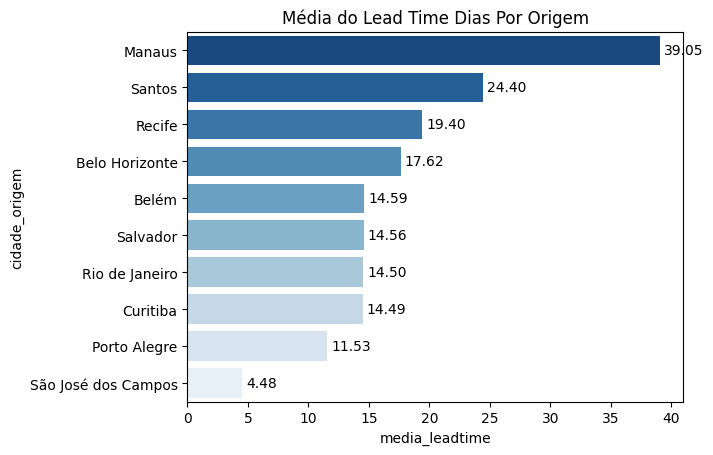

In [13]:


ax = sns.barplot(data=query, x='media_leadtime', y='cidade_origem', palette='Blues_r', hue='cidade_origem', legend=False)

ax.set_title('Média do Lead Time Dias Por Origem')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.show()

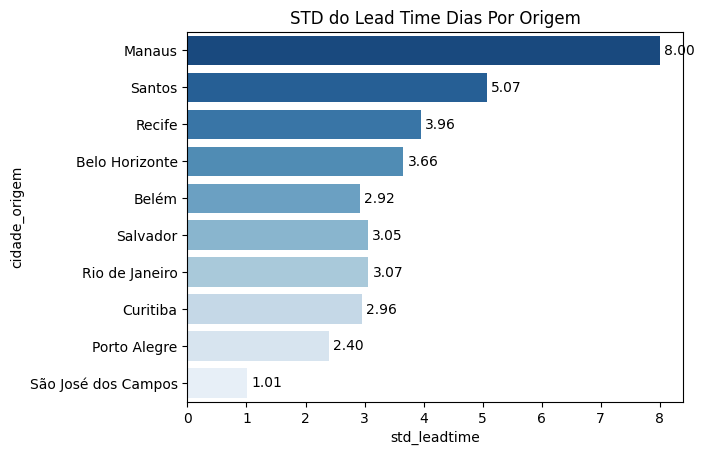

In [14]:


ax = sns.barplot(data=query, x='std_leadtime', y='cidade_origem', palette='Blues_r', hue='cidade_origem', legend=False)

ax.set_title('STD do Lead Time Dias Por Origem')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.show()

- **Query ocorrencias do status atrasado e lead time**

In [15]:
query = spark.sql("""SELECT
  cidade_origem,
  status,
  COUNT(*) AS ocorrencias,
  AVG(lead_time_dias) AS media_leadtime
FROM supply
WHERE status = 'Atrasado'
GROUP BY cidade_origem, status
ORDER BY ocorrencias DESC """).toPandas()
query.head()

,cidade_origem,status,ocorrencias,media_leadtime
0,Curitiba,Atrasado,482,14.427386
1,Salvador,Atrasado,482,14.738589
2,Belo Horizonte,Atrasado,478,17.769874
3,Santos,Atrasado,465,24.462366
4,Recife,Atrasado,454,19.528634


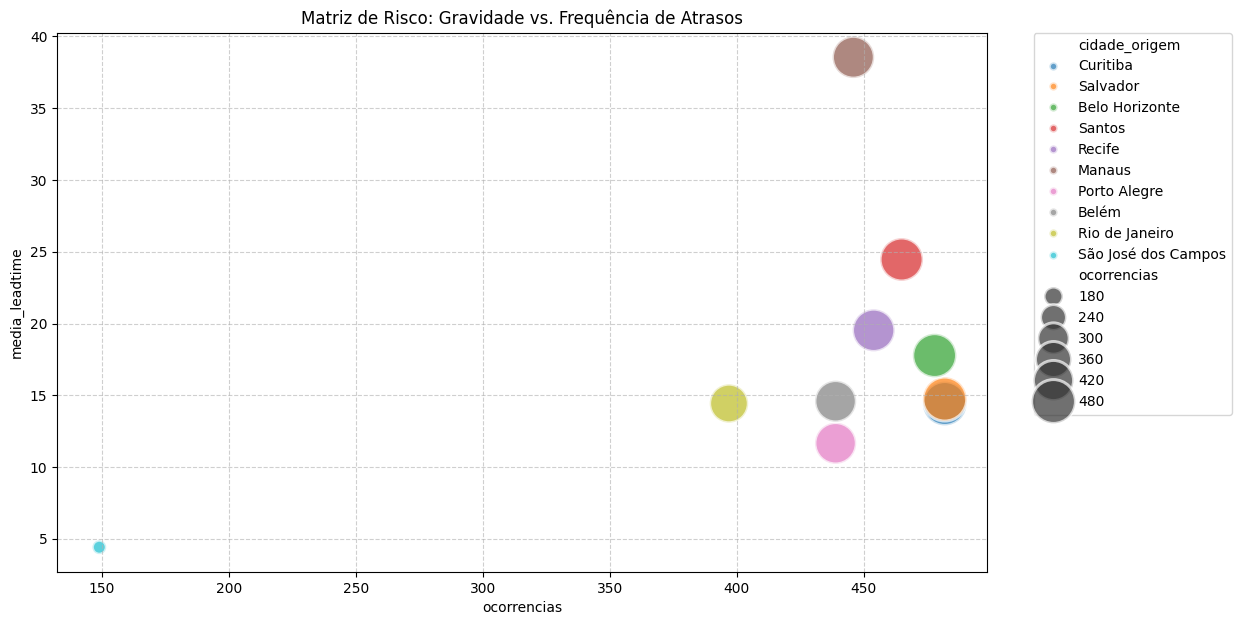

In [16]:

plt.figure(figsize=(12, 7))

ax = sns.scatterplot(
    data = query,
    x = 'ocorrencias',
    y = 'media_leadtime',
    hue = 'cidade_origem',
    size = 'ocorrencias', # O tamanho da bolha agora indica a frequência
    sizes = (100, 1000),  # Ajusta o tamanho das bolhas para ficarem visíveis
    alpha = 0.7           # Transparência para ver se uma bolha sobrepõe a outra
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.title('Matriz de Risco: Gravidade vs. Frequência de Atrasos')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

- **Query Landed Cost**

In [17]:
query = spark.sql("""SELECT
    CASE
        WHEN estado IN ('SP', 'RJ', 'MG', 'PR', 'RS') THEN 'Sul-Sudeste'
        ELSE 'Norte-Nordeste-Outros'
    END AS bloco_logistico,
    ROUND(AVG(custo_unitario + (custo_frete/quantidade)), 2) AS custo_total_por_peca,
    ROUND(AVG(lead_time_dias), 2) AS media_lead_time,
    ROUND(STDDEV(lead_time_dias), 2) AS std_lead_time
FROM supply
GROUP BY bloco_logistico
ORDER BY custo_total_por_peca desc""").toPandas()
query.head()

,bloco_logistico,custo_total_por_peca,media_lead_time,std_lead_time
0,Norte-Nordeste-Outros,21597.40,21.96,11.26
1,Sul-Sudeste,18931.27,14.46,6.89


/tmp/ipykernel_3955/55261270.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3955/55261270.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


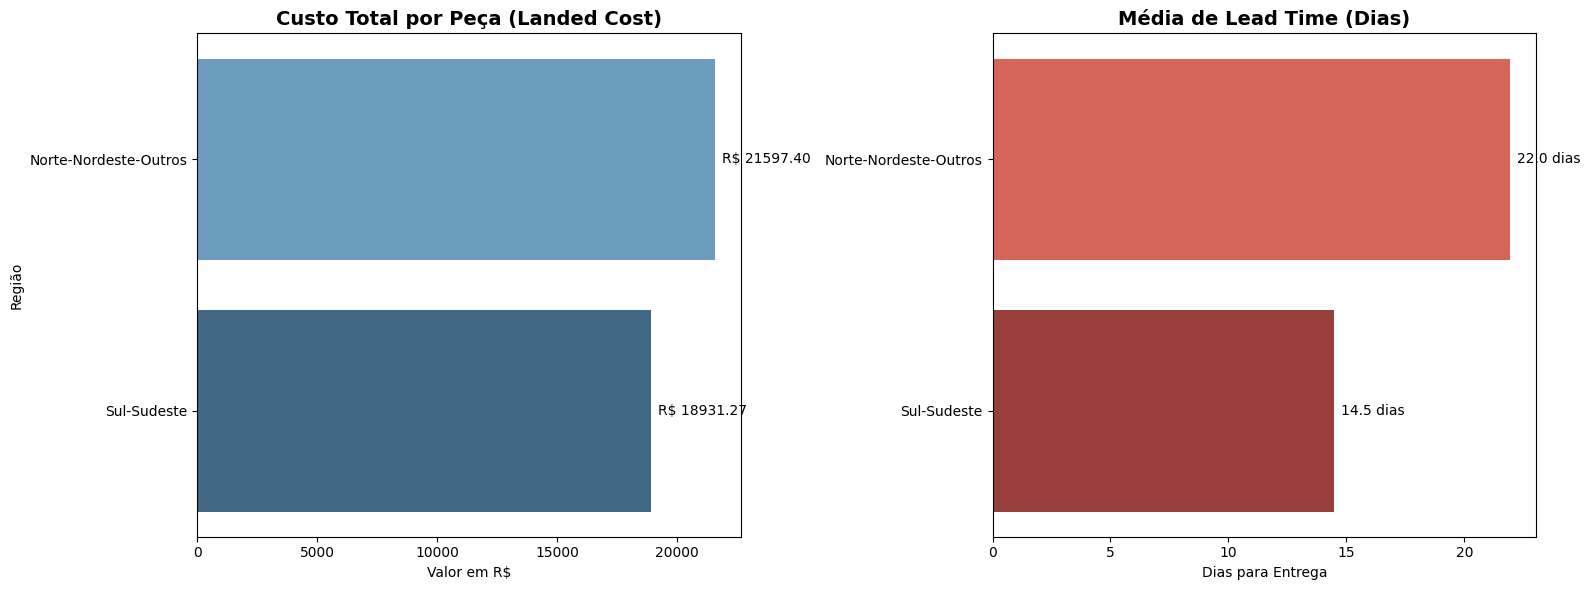

In [18]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=query,
    x='custo_total_por_peca',
    y='bloco_logistico',
    ax=ax1,
    palette='Blues_d'
)
ax1.set_title('Custo Total por Peça (Landed Cost)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Valor em R$')
ax1.set_ylabel('Região')

# Adicionando rótulos de dados no Custo
for container in ax1.containers:
    ax1.bar_label(container, fmt='R$ %.2f', padding=5)

sns.barplot(
    data=query,
    x='media_lead_time',
    y='bloco_logistico',
    ax=ax2,
    palette='Reds_d' # Cor vermelha para indicar tempo/atraso
)
ax2.set_title('Média de Lead Time (Dias)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Dias para Entrega')
ax2.set_ylabel('') # Remove o label lateral para não repetir

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f dias', padding=5)

plt.tight_layout()
plt.show()

- **Query categoria e lead time**

In [19]:
query = spark.sql("""
SELECT
    categoria,
    SUM(custo_frete) AS custo,
    ROUND(AVG(CAST(lead_time_dias AS INT)), 2) AS media_leadtime,
    ROUND(STDDEV(CAST(lead_time_dias AS INT)), 2) AS std_leadtime
FROM supply
GROUP BY categoria
ORDER BY custo DESC
""").toPandas()
query.head()

,categoria,custo,media_leadtime,std_leadtime
0,Química,1.951923e+06,17.75,9.92
1,Mecânica,1.922014e+06,17.43,9.61
2,Eletrônicos,1.882557e+06,17.28,9.45
3,Metalurgia,1.871291e+06,17.38,9.62
4,Embalagens,9.221937e+05,17.37,9.35


/tmp/ipykernel_3955/3582766819.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data = query, x = 'custo', y = 'categoria', palette = 'Blues_r')


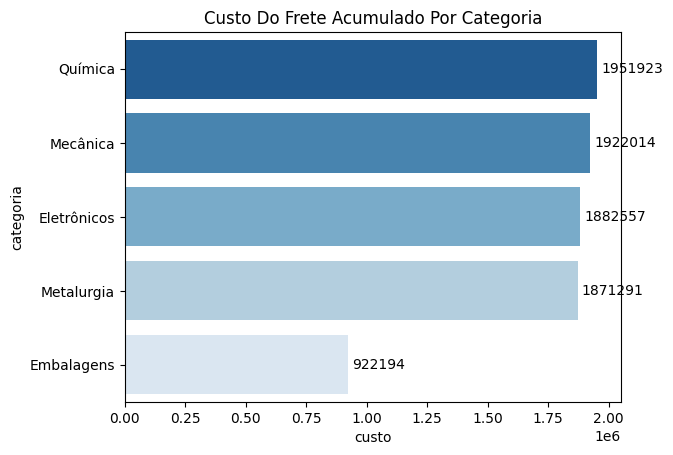

In [20]:
ax = sns.barplot(data = query, x = 'custo', y = 'categoria', palette = 'Blues_r')
ax.set_title('Custo Do Frete Acumulado Por Categoria')

for container in ax.containers:
  ax.bar_label(container, fmt='%2.f', padding=3)

plt.show()

# **Aplicando o modelo de Regressao Linear**

In [21]:
assembler = VectorAssembler(inputCols=['custo_frete'], outputCol='features')
X = assembler.transform(df)
lr = LinearRegression(featuresCol='features', labelCol='lead_time_dias')
model = lr.fit(X)

summary = model.summary
print(f"Intercepto: {model.intercept}")
print(f"Coeficiente (Inclinação): {model.coefficients}")
print(f"R2: {summary.r2}")

Intercepto: -15.381058485306324
Coeficiente (Inclinação): [0.05760012973412903]
R2: 0.7194216039414494


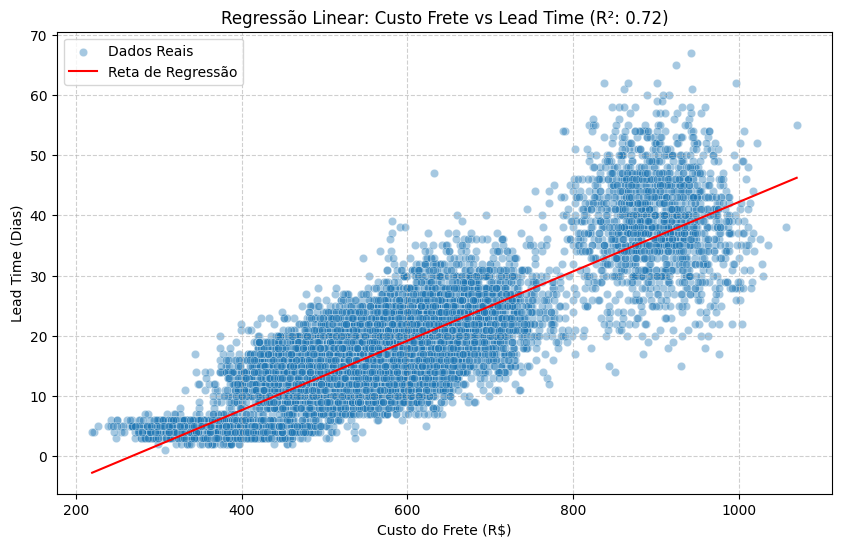

In [22]:

# 1. Pegando as predições do modelo para desenhar a reta
predictions = model.transform(X).select("custo_frete", "prediction", "lead_time_dias").toPandas()

# 2. Plotando
plt.figure(figsize=(10, 6))

# Desenha os pontos reais
sns.scatterplot(data=predictions, x='custo_frete', y='lead_time_dias', alpha=0.4, label='Dados Reais')

sns.lineplot(data=predictions, x='custo_frete', y='prediction', color='red', label='Reta de Regressão')

plt.title(f'Regressão Linear: Custo Frete vs Lead Time (R²: {summary.r2:.2f})')
plt.xlabel('Custo do Frete (R$)')
plt.ylabel('Lead Time (Dias)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# **Aplicando o modelo de Regressão Logistica**

In [23]:
data_model = VectorAssembler(
    inputCols=['custo_frete', 'quantidade'],
    outputCol='features'
).transform(
    StringIndexer(
        inputCol='status',
        outputCol='label'
    ).fit(df).transform(df)
)

lr_log = LogisticRegression(featuresCol='features', labelCol='label')
model = lr_log.fit(data_model)

In [24]:

print("Coeficientes por classe:")
print(model.coefficientMatrix)

print("\nInterceptos por classe:")
print(model.interceptVector)

predictions = model.transform(data_model)
predictions.select('status', 'label', 'prediction', 'probability').show(10)


Coeficientes por classe:
DenseMatrix([[-8.76311843e-04,  1.24397172e-04],
             [ 5.62817967e-04, -1.41389810e-04],
             [ 3.13493876e-04,  1.69926378e-05]])

Interceptos por classe:
[0.7595109161185715,-0.4302549831200252,-0.3292559329985463]
+-----------+-----+----------+--------------------+
|     status|label|prediction|         probability|
+-----------+-----+----------+--------------------+
|   Atrasado|  1.0|       0.0|[0.43731837575980...|
|Em trânsito|  2.0|       0.0|[0.40615100332638...|
|   Entregue|  0.0|       0.0|[0.37606665572425...|
|   Entregue|  0.0|       0.0|[0.42933985514431...|
|Em trânsito|  2.0|       0.0|[0.46546452081164...|
|   Entregue|  0.0|       0.0|[0.48723676965183...|
|   Entregue|  0.0|       0.0|[0.45757813747039...|
|Em trânsito|  2.0|       0.0|[0.41613670931917...|
|   Atrasado|  1.0|       0.0|[0.44168276582688...|
|   Entregue|  0.0|       0.0|[0.47604694009749...|
+-----------+-----+----------+--------------------+
only showing 

### **Aplicando o modelo de KMeans** ###

In [25]:
data_cluster = VectorAssembler(
    inputCols=['lead_time_dias', 'custo_frete', 'quantidade'],
    outputCol='features'
).transform(
    StringIndexer(
        inputCol='status',
        outputCol='label'
    ).fit(df).transform(df)
)
scaler = StandardScaler(inputCol='features', outputCol='scaledFeatures')
data_scaled = scaler.fit(data_cluster).transform(data_cluster)



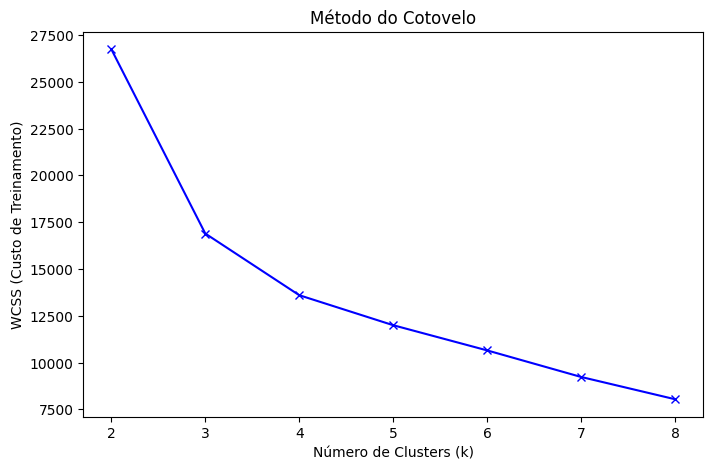

In [26]:
from pyspark.ml.clustering import KMeans
import matplotlib.pyplot as plt

# Lista para guardar o "erro" (WCSS)
cost = []

# Vamos testar de 2 a 8 grupos
for k in range(2, 9):
    kmeans = KMeans(featuresCol='scaledFeatures', k=k, seed=82)
    model = kmeans.fit(data_scaled)

    # No PySpark 3.x usamos o summary.trainingCost (que é o WCSS)
    cost.append(model.summary.trainingCost)

# Plotando o gráfico do Cotovelo
plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), cost, 'bx-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS (Custo de Treinamento)')
plt.title('Método do Cotovelo')
plt.show()

In [27]:
km = KMeans(featuresCol='scaledFeatures', k=4, seed=82)
model_km = km.fit(data_scaled)

result = model_km.transform(data_scaled)
result.groupBy('prediction').avg('custo_frete', 'lead_time_dias').orderBy('avg(custo_frete)').show()

+----------+-----------------+-------------------+
|prediction| avg(custo_frete)|avg(lead_time_dias)|
+----------+-----------------+-------------------+
|         0|405.2019221797468|  6.876808598594461|
|         3|557.9044499496947| 16.501466813348003|
|         2|559.7145574567254|  16.68732807628828|
|         1|881.0399106844922|  38.31182795698925|
+----------+-----------------+-------------------+



In [28]:
result.groupBy('prediction', 'cidade_origem').count().orderBy('prediction', 'count').show(40)

+----------+-------------------+-----+
|prediction|      cidade_origem|count|
+----------+-------------------+-----+
|         0|     Belo Horizonte|   15|
|         0|     Rio de Janeiro|   98|
|         0|              Belém|  101|
|         0|           Curitiba|  107|
|         0|           Salvador|  116|
|         0|       Porto Alegre|  457|
|         0|São José dos Campos| 1525|
|         1|             Recife|    2|
|         1|             Santos|  172|
|         1|             Manaus| 1500|
|         2|             Manaus|    4|
|         2|São José dos Campos|   21|
|         2|       Porto Alegre|  493|
|         2|     Rio de Janeiro|  644|
|         2|              Belém|  658|
|         2|             Santos|  689|
|         2|           Curitiba|  698|
|         2|           Salvador|  713|
|         2|             Recife|  742|
|         2|     Belo Horizonte|  791|
|         3|             Manaus|    3|
|         3|São José dos Campos|   14|
|         3|       Porto 